In [1]:
from neuromodes.TEMP_utils import plot_mesh_data
from nibabel.affines import apply_affine
from nibabel.loadsave import load
import numpy as np
from neuromodes import EigenSolver
from neuromodes.mesh import make_vol_mesh, tetmesh_to_nifti, nifti_to_tetmesh
import matplotlib.pyplot as plt
from nilearn.plotting import plot_stat_map

neuromodes = 'C:/Users/ipop0003/neuromodes'

In [2]:
# Get NIFTI and make volumetric mesh
niftipath = f'{neuromodes}/TEMP_investigations/hcp_hippo-lh_thr25.nii.gz'
nifti = load(niftipath)

vol = make_vol_mesh(nifti, method='tetgen')

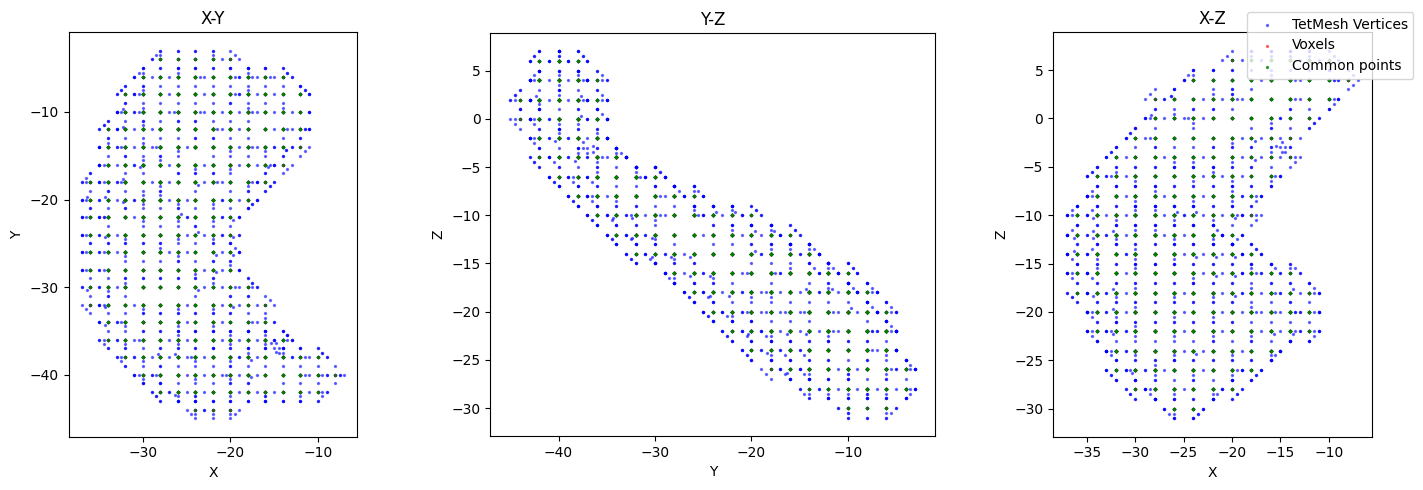

Number of mesh vertices: 2178
Number of voxels: 952
Number of common points: 952


In [3]:
s = 2

# plot x-y, y-z, x-z coords of surface and voxels in world space as subplots
xyz = np.column_stack(np.where(nifti.get_fdata() > 0))      # (i,j,k) = (z,y,x)
xyz = apply_affine(nifti.affine, xyz)       # world space

# get points that are in both the surface vertices and the voxel centers, accounting for numerical precision issues
surf_verts = vol.v
surf_verts_rounded = np.round(surf_verts, decimals=5)
xyz_rounded = np.round(xyz, decimals=5)
common_verts = np.intersect1d(surf_verts_rounded.view([('', surf_verts_rounded.dtype)] * surf_verts_rounded.shape[1]),
                             xyz_rounded.view([('', xyz_rounded.dtype)] * xyz_rounded.shape[1]))
common_verts = common_verts.view(surf_verts_rounded.dtype).reshape(-1, surf_verts_rounded.shape[1])

# Set up subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# x-y plot
sc1 = axes[0].scatter(vol.v[:, 0], vol.v[:, 1], s=s, color='blue', label='TetMesh Vertices', alpha=0.5)
sc2 = axes[0].scatter(xyz[:, 0], xyz[:, 1], s=s, color='red', label='Voxels', alpha=0.5)
sc3 = axes[0].scatter(common_verts[:, 0], common_verts[:, 1], s=s, color='green', label='Common points', alpha=0.7)
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].set_aspect('equal', adjustable='box')
axes[0].set_title('X-Y')

# y-z plot
axes[1].scatter(vol.v[:, 1], vol.v[:, 2], s=s, color='blue', alpha=0.5)
axes[1].scatter(xyz[:, 1], xyz[:, 2], s=s, color='red', alpha=0.5)
axes[1].scatter(common_verts[:, 1], common_verts[:, 2], s=s, color='green', alpha=0.7)
axes[1].set_xlabel('Y')
axes[1].set_ylabel('Z')
axes[1].set_aspect('equal', adjustable='box')
axes[1].set_title('Y-Z')

# x-z plot
axes[2].scatter(vol.v[:, 0], vol.v[:, 2], s=s, color='blue', alpha=0.5)
axes[2].scatter(xyz[:, 0], xyz[:, 2], s=s, color='red', alpha=0.5)
axes[2].scatter(common_verts[:, 0], common_verts[:, 2], s=s, color='green', alpha=0.7)
axes[2].set_xlabel('X')
axes[2].set_ylabel('Z')
axes[2].set_aspect('equal', adjustable='box')
axes[2].set_title('X-Z')

# Add a single legend to the figure
handles = [sc1, sc2, sc3]
labels = [h.get_label() for h in handles]
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.98, 0.98))

plt.tight_layout()
plt.show()

# print number of vertices in surface, number of voxels, and number of common points
print(f'Number of mesh vertices: {vol.v.shape[0]}')
print(f'Number of voxels: {xyz.shape[0]}')
print(f'Number of common points: {common_verts.shape[0]}')

In [4]:
# Solve eigenmodes on volumetric mesh
solver = EigenSolver(vol).solve(10)

# Visualise tetmesh
plot_mesh_data(vol, solver.emodes[:, 7])

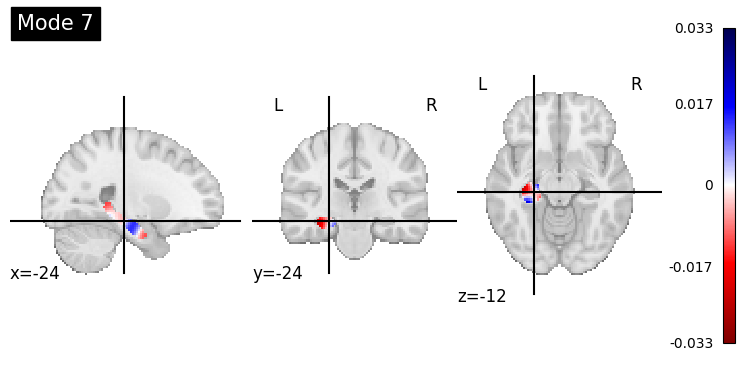

In [5]:
# Try transformation function
mode_nifti = tetmesh_to_nifti(solver.emodes[:, 7], solver.geometry, nifti)

plot_stat_map(mode_nifti, display_mode='ortho', cmap='seismic_r', symmetric_cbar=True, title='Mode 7')

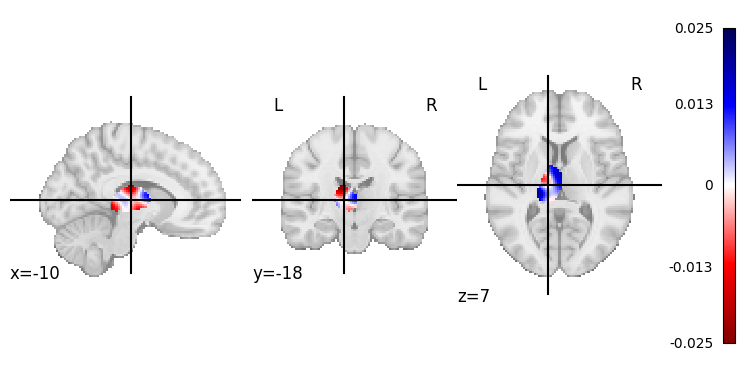

In [6]:
# Try thalamus and striatum
niftipath = f'{neuromodes}/TEMP_investigations/hcp_tha-lh_thr25.nii.gz'
nifti = load(niftipath)

vol = make_vol_mesh(nifti, method='tetgen')
solver = EigenSolver(vol).solve(10)
plot_mesh_data(vol, solver.emodes[:, 7])
mode_nifti = tetmesh_to_nifti(solver.emodes[:, 7], solver.geometry, nifti)
plot_stat_map(mode_nifti, display_mode='ortho', cmap='seismic_r')

In [2]:
# Try striatum
niftipath = f'{neuromodes}/TEMP_investigations/hcp_striatum-lh_thr25.nii.gz'
nifti = load(niftipath)

vol = make_vol_mesh(nifti, discard_components=True)#, method='tetgen', minratio=1.1, mindihedral=10)
solver = EigenSolver(vol).solve(100)

Components discarded: 1.
    - 6 vertices.


### nifti_to_tetmesh interp

Correlation between original and interpolated values at vertices: 0.6683


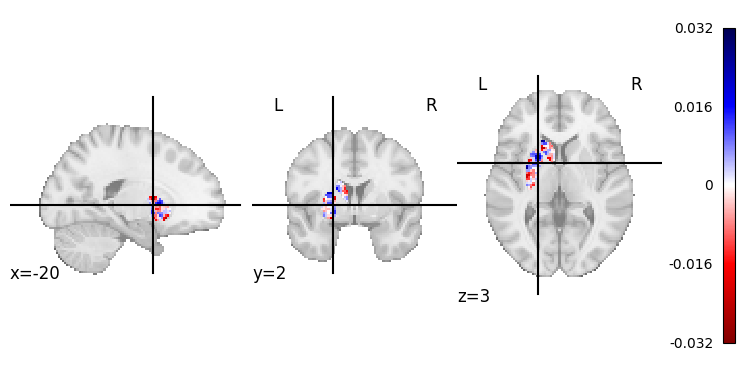

In [3]:
plot_mesh_data(vol, solver.emodes[:, -1], cmap_center=0)
mode_nifti = tetmesh_to_nifti(solver.emodes[:, -1], solver.geometry, nifti)
plot_stat_map(mode_nifti, display_mode='ortho', cmap='seismic_r')

mode_tetmesh = nifti_to_tetmesh(mode_nifti, vol)
plot_mesh_data(vol, mode_tetmesh, cmap_center=0)

# Print correlation between original and interpolated values at vertex locations
corr = np.corrcoef(solver.emodes[:, -1], mode_tetmesh)[0, 1]
print(f'Correlation between original and interpolated values at vertices: {corr:.4f}')